# Trabalho Prático 1 - Métodos de Busca (UCS e A*)
**Departamento de Informática e Estatística - UFSC**  
**Curso:** Sistemas de Informação  
**Disciplina:** Sistemas Inteligentes  
**Professora:** Nathalia da Cruz Alves  

---

### Identificação da Equipe (A1.1)
- **Estudante 1:** Luiz Eduardo — *Contribuição: Modelagem do espaço de estados, implementação da classe Maze e gerador de instâncias.*
- **Estudante 2:** [Nome do Estudante] — *Contribuição: Implementação do algoritmo de busca genérico (UCS e A*), formulação das heurísticas e coleta das métricas.*
- **Estudante 3 (opcional):** [Nome do Estudante] — *Contribuição: Estruturação dos cenários fácil e difícil, análise comparativa e roteiro do vídeo.*

---

## 1. Descrição do Problema e Formulação no Espaço de Estados (A1.1)

O problema escolhido é a **Navegação em Labirinto em uma Matriz 2D** (Tema 2.a dos requisitos):
- **Espaço de Estados:** O conjunto de todas as coordenadas discretas `(linha, coluna)` no grid bidimensional de dimensões $H 	imes W$. Cada célula representa uma posição no labirinto.
- **Estado Inicial:** A coordenada de partida `start = (r_start, c_start)`.
- **Estado / Condição Objetivo:** A coordenada de destino `goal = (r_goal, c_goal)`.
- **Ações / Movimentos Possíveis:** O agente pode se mover ortogonalmente em até 4 direções:
  - Cima: `(r - 1, c)`
  - Baixo: `(r + 1, c)`
  - Esquerda: `(r, c - 1)`
  - Direita: `(r, c + 1)`
  Um movimento é válido se e somente se a posição de destino estiver dentro dos limites da matriz e não pertencer ao conjunto de paredes (`walls`).
- **Custo das Ações:** Custo unitário uniforme ($c = 1.0$) para cada deslocamento entre células adjacentes livres.


In [1]:
from __future__ import annotations

import heapq
import math
import time
from random import Random
from typing import Iterable, Optional, Sequence

# Tipo para coordenadas discretas (linha, coluna)
Position = tuple[int, int]


In [2]:

class Maze:
    """Representação de um labirinto em grade retangular.
    
    - As dimensões (altura e largura) são informadas no construtor.
    - As paredes ('walls') são informadas exclusivamente como uma lista/coleção 
      de coordenadas (linha, coluna).
    - 'start' e 'goal' são obrigatórios.
    """

    WALL = "#"
    OPEN = " "
    START = "S"
    GOAL = "G"
    PATH = "·"

    def __init__(
        self,
        height: int,
        width: int,
        walls: Iterable[Position],
        start: Position,
        goal: Position,
    ) -> None:
        if isinstance(height, bool) or isinstance(width, bool):
            raise TypeError("height e width devem ser inteiros")
        if not isinstance(height, int) or not isinstance(width, int):
            raise TypeError("height e width devem ser inteiros")
        if height < 2 or width < 2:
            raise ValueError("o labirinto precisa ter pelo menos 2 linhas e 2 colunas")
        if walls is None:
            raise ValueError("walls não pode ser None")
        if start is None:
            raise ValueError("start não pode ser None")
        if goal is None:
            raise ValueError("goal não pode ser None")

        self.height = self.rows = height
        self.width = self.columns = width
        self.walls: set[Position] = set(walls)

        for wall_pos in self.walls:
            self._validate_position(wall_pos, "wall")

        self.start = start
        self.goal = goal
        self._validate_position(self.start, "start")
        self._validate_position(self.goal, "goal")

        if self.is_wall(self.start) or self.is_wall(self.goal):
            raise ValueError("start e goal devem ser posições livres (não paredes)")

    @property
    def size(self) -> tuple[int, int]:
        """Retorna as dimensões (altura, largura)."""
        return self.rows, self.columns

    def _validate_position(self, position: Position, label: str = "position") -> None:
        if (
            not isinstance(position, tuple)
            or len(position) != 2
            or not all(isinstance(v, int) for v in position)
        ):
            raise TypeError(f"{label} deve ser uma tupla (linha, coluna)")
        r, c = position
        if not (0 <= r < self.rows and 0 <= c < self.columns):
            raise ValueError(f"{label} {position} está fora dos limites do labirinto")

    def is_wall(self, position: Position) -> bool:
        """Verifica se a coordenada é uma parede."""
        self._validate_position(position)
        return position in self.walls

    def is_walkable(self, position: Position) -> bool:
        """Verifica se a célula está nos limites e livre para passagem."""
        r, c = position
        return (
            0 <= r < self.rows
            and 0 <= c < self.columns
            and position not in self.walls
        )

    def neighbors(self, position: Position) -> Iterable[Position]:
        """Gera os vizinhos válidos nos 4 sentidos (Cima, Direita, Baixo, Esquerda)."""
        r, c = position
        for next_pos in (
            (r - 1, c),
            (r, c + 1),
            (r + 1, c),
            (r, c - 1),
        ):
            if self.is_walkable(next_pos):
                yield next_pos

    def get_matrix(
        self, path: Optional[Sequence[Position]] = None
    ) -> list[list[str]]:
        """Retorna a matriz 2D de células.
        
        Se um caminho for informado, as células do caminho são preenchidas com
        os índices sequenciais dos passos, iniciando em '0' no start.
        """
        path_map: dict[Position, str] = {}
        if path is not None:
            path_list = list(path)
            if path_list and self.start not in path_list:
                path_list = [self.start] + path_list
            for step, pos in enumerate(path_list):
                path_map[pos] = str(step)

        matrix: list[list[str]] = []
        for r in range(self.rows):
            line: list[str] = []
            for c in range(self.columns):
                pos = (r, c)
                if pos in path_map:
                    line.append(path_map[pos])
                elif pos == self.start:
                    line.append(self.START)
                elif pos == self.goal:
                    line.append(self.GOAL)
                elif pos in self.walls:
                    line.append(self.WALL)
                else:
                    line.append(self.OPEN)
            matrix.append(line)
        return matrix

    def render(self, path: Optional[Sequence[Position]] = None) -> str:
        """Retorna a representação textual formatada e alinhada do labirinto."""
        matrix = self.get_matrix(path)
        max_len = max(len(cell) for row in matrix for cell in row)
        use_spaces = path is not None or max_len > 1
        if use_spaces:
            text = "\n".join(
                " ".join(f"{cell:>{max_len}}" for cell in row) for row in matrix
            )
        else:
            text = "\n".join("".join(row) for row in matrix)
        return text

In [3]:
class MazeGenerator:
    """Fábrica de labirintos conectados usando recursive backtracking."""

    def __init__(
        self,
        height: int,
        width: int,
        *,
        seed: Optional[int] = None,
        loop_probability: float = 0.0,
    ) -> None:
        self._validate_dimension(height, "height")
        self._validate_dimension(width, "width")
        if height < 2 or width < 2:
            raise ValueError("o labirinto precisa ter pelo menos 2 linhas e 2 colunas")
        if not 0.0 <= loop_probability <= 1.0:
            raise ValueError("loop_probability deve estar entre 0 e 1")

        self.height = self.rows = height
        self.width = self.columns = width
        self.loop_probability = loop_probability
        self.random = Random(seed)

    @staticmethod
    def _validate_dimension(value: int, name: str) -> None:
        """Valida uma dimensão do labirinto."""
        if isinstance(value, bool) or not isinstance(value, int):
            raise TypeError(f"{name} deve ser um inteiro")

    def generate(self) -> "Maze":
        """Gera e retorna uma nova instância de Maze."""
        lattice = self._lattice_cells()
        if len(lattice) < 2:
            return self._create_open_maze()

        grid = self._create_wall_grid()
        self._carve_passages(grid, lattice)
        self._add_loops(grid)

        start = lattice[0]
        goal = self._farthest_cell(grid, start)
        walls = self._wall_coordinates(grid)

        return Maze(
            height=self.height,
            width=self.width,
            walls=walls,
            start=start,
            goal=goal,
        )

    def _lattice_cells(self) -> list[Position]:
        """Retorna as células internas usadas como pontos do labirinto."""
        return [
            (row, column)
            for row in range(1, self.height - 1, 2)
            for column in range(1, self.width - 1, 2)
        ]

    def _create_wall_grid(self) -> list[list[bool]]:
        """Cria uma grade em que True representa parede e False representa passagem."""
        return [
            [True for _ in range(self.width)]
            for _ in range(self.height)
        ]

    def _carve_passages(
        self,
        grid: list[list[bool]],
        lattice: list[Position],
    ) -> None:
        """Abre corredores conectando todas as células da lattice."""
        start = lattice[0]
        visited = {start}
        stack = [start]
        grid[start[0]][start[1]] = False

        while stack:
            current = stack[-1]
            candidates = [
                cell
                for cell in self._lattice_neighbors(current)
                if cell not in visited
            ]

            if not candidates:
                stack.pop()
                continue

            next_cell = self.random.choice(candidates)
            between = (
                (current[0] + next_cell[0]) // 2,
                (current[1] + next_cell[1]) // 2,
            )

            grid[between[0]][between[1]] = False
            grid[next_cell[0]][next_cell[1]] = False
            visited.add(next_cell)
            stack.append(next_cell)

    def _lattice_neighbors(self, cell: Position) -> list[Position]:
        """Retorna os vizinhos da lattice separados por uma célula."""
        row, column = cell
        neighbors = []
        for next_cell in (
            (row - 2, column),
            (row, column + 2),
            (row + 2, column),
            (row, column - 2),
        ):
            next_row, next_column = next_cell
            if (
                1 <= next_row < self.height - 1
                and 1 <= next_column < self.width - 1
            ):
                neighbors.append(next_cell)
        return neighbors

    def _add_loops(self, grid: list[list[bool]]) -> None:
        """Remove algumas paredes internas para criar caminhos alternativos."""
        for row in range(1, self.height - 1):
            for column in range(1, self.width - 1):
                if not grid[row][column]:
                    continue
                if self.random.random() > self.loop_probability:
                    continue

                open_neighbors = sum(
                    not grid[next_row][next_column]
                    for next_row, next_column in (
                        (row - 1, column),
                        (row + 1, column),
                        (row, column - 1),
                        (row, column + 1),
                    )
                    if 0 <= next_row < self.height
                    and 0 <= next_column < self.width
                )
                if open_neighbors >= 2:
                    grid[row][column] = False

    def _farthest_cell(self, grid: list[list[bool]], start: Position) -> Position:
        """Encontra a célula aberta mais distante de start por busca em largura."""
        distances = {start: 0}
        queue = [start]

        for current in queue:
            row, column = current
            for neighbor in (
                (row - 1, column),
                (row, column + 1),
                (row + 1, column),
                (row, column - 1),
            ):
                next_row, next_column = neighbor
                if not (
                    0 <= next_row < self.height
                    and 0 <= next_column < self.width
                ):
                    continue
                if grid[next_row][next_column] or neighbor in distances:
                    continue

                distances[neighbor] = distances[current] + 1
                queue.append(neighbor)

        return max(distances.items(), key=lambda item: item[1])[0]

    def _wall_coordinates(self, grid: list[list[bool]]) -> set[Position]:
        """Converte a grade booleana no conjunto de paredes do Maze."""
        return {
            (row, column)
            for row in range(self.height)
            for column in range(self.width)
            if grid[row][column]
        }

    def _create_open_maze(self) -> "Maze":
        """Cria um labirinto aberto para dimensões sem lattice suficiente."""
        return Maze(
            height=self.height,
            width=self.width,
            walls=[],
            start=(0, 0),
            goal=(self.height - 1, self.width - 1),
        )


print("Classe MazeGenerator compilada com sucesso!")


Classe MazeGenerator compilada com sucesso!


## Funcionamento teórico do `MazeGenerator`

O `MazeGenerator` funciona como uma **factory de labirintos**: ele recebe as dimensões do ambiente e devolve um objeto `Maze` completo, contendo `walls`, `start`, `goal`, `height` e `width`.

### Representação do estado

Durante a geração, o labirinto é representado por uma grade booleana:

- `True` representa uma parede;
- `False` representa uma passagem.

A grade começa completamente preenchida por paredes. Em seguida, o algoritmo abre apenas os corredores necessários.

As células principais do labirinto são obtidas por `_lattice_cells()`. Elas ficam em coordenadas internas separadas por duas posições, como `(1, 1)`, `(1, 3)` e `(3, 1)`. A posição entre duas células da lattice representa a parede que será removida para conectá-las.

### Algoritmo utilizado: Recursive Backtracking

A geração usa o algoritmo **Recursive Backtracking**, uma variação de busca em profundidade (`DFS`) aleatória. Nesta implementação, a recursão foi substituída por uma lista chamada `stack`, que guarda o caminho atual.

O algoritmo mantém duas estruturas principais:

- `visited`: conjunto das células da lattice que já foram visitadas;
- `stack`: caminho de células que ainda pode ser explorado.

A cada iteração:

1. A célula no topo da pilha é considerada a célula atual.
2. O gerador procura vizinhos da lattice que ainda não foram visitados.
3. Se existir um vizinho, um deles é escolhido aleatoriamente.
4. A parede entre a célula atual e o vizinho é removida.
5. O vizinho é marcado como visitado e colocado na pilha.
6. Se não houver vizinhos disponíveis, a célula é removida da pilha. Esse é o retrocesso (*backtracking*).

Como cada nova célula só é alcançada a partir de uma célula já conectada, todas as células abertas pertencem ao mesmo componente. Por isso, o labirinto gerado possui um caminho entre o início e todas as demais áreas abertas.

### Escolha do início e do objetivo

O início é a primeira célula da lattice, normalmente `(1, 1)`. Depois que os corredores são construídos, `_farthest_cell()` executa uma busca em largura (`BFS`) a partir do início e escolhe como objetivo a célula aberta mais distante.

Essa escolha cria um problema de busca mais interessante do que escolher um objetivo aleatório, pois o caminho tende a atravessar uma parte maior do labirinto.

Quando `loop_probability` é maior que zero, `_add_loops()` remove algumas paredes internas que possuem pelo menos duas passagens vizinhas. Isso cria caminhos alternativos e deixa o labirinto menos parecido com uma árvore.

### Fluxo de execução

```plantuml
@startuml
start
:Validar altura, largura e loop_probability;
:Construir células da lattice;

if (Há pelo menos duas células?) then (não)
  :Criar Maze aberto;
  stop
else (sim)
  :Criar grade preenchida com paredes;
  :Escolher a primeira célula;
  :Marcar início como passagem;
  :Adicionar início à stack e ao visited;
endif

while (A stack não está vazia?) is (sim)
  :Obter célula no topo da stack;
  :Procurar vizinhos da lattice não visitados;

  if (Existe vizinho disponível?) then (sim)
    :Escolher um vizinho aleatoriamente;
    :Remover a parede entre as duas células;
    :Abrir e visitar o vizinho;
    :Adicionar o vizinho à stack;
  else (não)
    :Remover a célula da stack;
  endif
endwhile (não)

if (loop_probability > 0?) then (sim)
  :Remover algumas paredes internas;
endif

:Encontrar a passagem mais distante com BFS;
:Converter a grade em conjunto de walls;
:Retornar Maze(start, goal, walls, height, width);
stop
@enduml
```

### Complexidade

Para uma grade com `H` linhas e `W` colunas:

- **Tempo:** `O(H × W)`, pois a grade é percorrida para gerar os corredores, procurar o objetivo e coletar as paredes;
- **Memória:** `O(H × W)`, devido à grade, ao conjunto `visited`, à fila da BFS e à `stack`;
- **Resultado:** uma instância de `Maze` pronta para ser usada pelos algoritmos UCS e A*.


## 2. Algoritmos e Heurísticas (A1.2 e A2.2 / A2.3)

O algoritmo **A\*** avalia cada nó pela função:
$$f(n) = g(n) + h(n)$$
onde:
- $g(n)$ é o custo real acumulado do nó inicial até o nó $n$.
- $h(n)$ é a estimativa heurística do custo restante de $n$ até o objetivo.

### As 4 Variações Consideradas

Cada heurística abaixo é documentada em uma célula Markdown própria e implementada imediatamente na célula de código seguinte.


### 1. UCS — Busca de Custo Uniforme

O UCS não utiliza informação heurística para estimar a distância até o objetivo. Por isso:

$$h_{UCS}(n) = 0$$

A função de prioridade torna-se:

$$f(n) = g(n) + h(n) = g(n)$$

Assim, o algoritmo sempre escolhe o estado com menor custo acumulado desde o início. Como todos os movimentos do `Maze` possuem custo unitário, o UCS expande os estados em ordem crescente do número de passos.

Essa heurística é admissível porque nunca superestima o custo restante: ela sempre retorna zero.


In [4]:
# Heurística do UCS (Uniform Cost Search)
#
# O UCS não estima o custo restante até o objetivo. Por isso, h(n) = 0
# para qualquer estado n. A escolha dos estados será feita apenas pelo
# custo acumulado g(n), controlado pela futura fila de prioridade.

def h_ucs(position: Position, goal: Position) -> float:
    """Retorna zero para qualquer estado, como definido pelo UCS."""
    return 0.0


### 2. A* com Heurística Euclidiana Admissível

A distância Euclidiana mede a distância em linha reta entre a posição atual e o objetivo:

$$h_{eucl}(n) = \sqrt{(r_n - r_{goal})^2 + (c_n - c_{goal})^2}$$

Ela é admissível porque a distância real em um `Maze` com movimentos ortogonais nunca pode ser menor que a distância em linha reta:

$$0 \le h_{eucl}(n) \le h^*(n)$$

Portanto, o A* mantém a garantia de encontrar um caminho ótimo quando utiliza essa heurística.


In [5]:
# Heurística Euclidiana (admissível)
#
# Representa a distância em linha reta entre a posição atual e o objetivo.

def h_admissible_euclidean(position: Position, goal: Position) -> float:
    """Retorna a distância Euclidiana entre position e goal."""
    row_distance = position[0] - goal[0]
    column_distance = position[1] - goal[1]
    return math.sqrt(row_distance ** 2 + column_distance ** 2)


### 3. A* com Heurística Manhattan

A distância Manhattan soma as diferenças absolutas entre as linhas e as colunas:

$$h_{manh}(n) = |r_n - r_{goal}| + |c_n - c_{goal}|$$

Como o agente se movimenta apenas na vertical e na horizontal, essa heurística representa o menor número de movimentos possível quando não existem paredes.

Ela é admissível e consistente. Além disso, domina a heurística Euclidiana:

$$h_{eucl}(n) \le h_{manh}(n) \le h^*(n)$$

Por ser mais informativa sem superestimar o custo, tende a expandir menos estados que a heurística Euclidiana.


In [6]:
# Heurística Manhattan (admissível e consistente)
#
# Em um Maze com movimentos apenas ortogonais, soma as diferenças
# de linha e coluna até o objetivo.

def h_consistent_manhattan(position: Position, goal: Position) -> float:
    """Retorna a distância Manhattan entre position e goal."""
    row_distance = abs(position[0] - goal[0])
    column_distance = abs(position[1] - goal[1])
    return float(row_distance + column_distance)


### 4. A* com Heurística Manhattan Ponderada

A heurística ponderada multiplica a distância Manhattan por um peso `w` maior que 1:

$$h_{inadm}(n) = w \times h_{manh}(n), \quad w > 1$$

Nesta implementação, o peso padrão é `w = 4.0`.

Como o valor pode ser maior que o custo real restante, essa heurística não é admissível. Por exemplo, se a distância Manhattan for `2`, a estimativa ponderada será `8` quando `w = 4`.

Ela pode direcionar a busca mais agressivamente ao objetivo, mas perde a garantia teórica de encontrar sempre o caminho ótimo.


In [7]:
# Heurística Manhattan ponderada (não admissível)
#
# O peso maior que 1 aumenta artificialmente a estimativa e pode
# fazer o A* priorizar caminhos aparentemente mais próximos do objetivo.

def h_inadmissible_weighted(
    position: Position,
    goal: Position,
    w: float = 40.0,
) -> float:
    """Retorna a distância Manhattan multiplicada por um peso maior que 1."""
    if w <= 1.0:
        raise ValueError("w deve ser maior que 1 para ser não admissível")
    return w * h_consistent_manhattan(position, goal)


### Busca genérica para UCS e A*

A busca recebe um `Maze` e uma função heurística. A mesma implementação atende aos dois algoritmos:

- no UCS, `h(n) = 0`, então a prioridade é apenas `g(n)`;
- no A*, a prioridade é `f(n) = g(n) + h(n)`.

A fronteira é uma fila de prioridade (`heapq`). Para cada posição, `cost_so_far` guarda o menor custo acumulado conhecido. Um sucessor só entra na fronteira quando é novo ou quando foi encontrado por um caminho mais barato.

Entradas antigas que ficaram na fila depois de uma atualização de custo são descartadas quando retiradas. A busca termina ao retirar o objetivo da fronteira, reconstruindo o caminho pelos ponteiros `parent`.

A função também coleta as métricas exigidas pelo trabalho: nós visitados, tamanho do caminho, tempo de execução e maior tamanho da fronteira.


In [8]:
class SearchNode:
    """Nó da fronteira com posição, pai e custos g, h e f."""

    def __init__(
        self,
        position: Position,
        parent: Optional["SearchNode"] = None,
        g: float = 0.0,
        h: float = 0.0,
    ) -> None:
        self.position = position
        self.parent = parent
        self.g = g
        self.h = h
        self.f = g + h


def _reconstruct_path(node: SearchNode) -> list[Position]:
    """Reconstrói o caminho do início até o nó objetivo."""
    path = []
    current: Optional[SearchNode] = node
    while current is not None:
        path.append(current.position)
        current = current.parent
    path.reverse()
    return path


def search_maze(
    maze: Maze,
    heuristic_fn,
    algorithm_name: str = "A*",
) -> dict:
    """Executa UCS ou A* e retorna o caminho, a exploração e as métricas."""
    start_time = time.perf_counter()

    start_h = heuristic_fn(maze.start, maze.goal)
    start_node = SearchNode(maze.start, g=0.0, h=start_h)

    # Cada item é (prioridade f, heurística h, desempate, nó).
    frontier: list[tuple[float, float, int, SearchNode]] = []
    tie_breaker = 0
    heapq.heappush(
        frontier,
        (start_node.f, start_node.h, tie_breaker, start_node),
    )

    # Menor custo g conhecido para cada posição.
    cost_so_far: dict[Position, float] = {maze.start: 0.0}
    explored_order: list[Position] = []
    nodes_visited = 0
    max_frontier_size = 1

    while frontier:
        max_frontier_size = max(max_frontier_size, len(frontier))
        _, _, _, current = heapq.heappop(frontier)

        # Ignora uma entrada antiga cujo custo já foi superado.
        if current.g != cost_so_far.get(current.position):
            continue

        nodes_visited += 1
        explored_order.append(current.position)

        if current.position == maze.goal:
            path = _reconstruct_path(current)
            execution_time = time.perf_counter() - start_time
            return {
                "status": "SUCESSO",
                "algorithm": algorithm_name,
                "path": path,
                "explored_order": explored_order,
                "nodes_visited": nodes_visited,
                "path_length": len(path) - 1,
                "execution_time_sec": execution_time,
                "max_frontier_size": max_frontier_size,
                "cost": current.g,
            }

        for next_position in maze.neighbors(current.position):
            new_cost = current.g + 1.0
            previous_cost = cost_so_far.get(next_position)

            if previous_cost is not None and new_cost >= previous_cost:
                continue

            cost_so_far[next_position] = new_cost
            next_h = heuristic_fn(next_position, maze.goal)
            next_node = SearchNode(
                next_position,
                parent=current,
                g=new_cost,
                h=next_h,
            )
            tie_breaker += 1
            heapq.heappush(
                frontier,
                (next_node.f, next_node.h, tie_breaker, next_node),
            )

    execution_time = time.perf_counter() - start_time
    return {
        "status": "FALHA",
        "algorithm": algorithm_name,
        "path": [],
        "explored_order": explored_order,
        "nodes_visited": nodes_visited,
        "path_length": 0,
        "execution_time_sec": execution_time,
        "max_frontier_size": max_frontier_size,
        "cost": None,
    }


In [9]:
try:
    from IPython.display import clear_output
except ImportError:
    def clear_output(wait: bool = False) -> None:
        """Mantém a visualização funcional fora de um ambiente Jupyter."""
        pass


def _render_exploration_state(
    maze: Maze,
    explored: list[Position],
    current: Optional[Position] = None,
) -> str:
    """Renderiza os estados expandidos e o estado atual da busca."""
    matrix = maze.get_matrix()
    explored_set = set(explored)

    for row, column in explored_set:
        position = (row, column)
        if position not in {maze.start, maze.goal} and position not in maze.walls:
            matrix[row][column] = "·"

    if current is not None:
        row, column = current
        if current not in {maze.start, maze.goal}:
            matrix[row][column] = "@"

    return "\n".join("".join(row) for row in matrix)


def visualize_search_process(
    maze: Maze,
    result: dict,
    delay: float = 0.15,
    clear: bool = True,
) -> None:
    """Anima os estados expandidos e exibe o caminho final ao terminar."""
    explored_order = result.get("explored_order", [])
    if not explored_order:
        print("Nenhum estado foi explorado.")
        return

    total_expanded = len(explored_order)
    for step, current in enumerate(explored_order, start=1):
        if clear:
            clear_output(wait=True)

        print(f"Expansão {step}/{total_expanded}")
        print("Legenda: @ estado atual | · estados já expandidos | # parede")
        print(_render_exploration_state(maze, explored_order[:step], current))

        if delay > 0 and step < total_expanded:
            time.sleep(delay)

    if result.get("status") == "SUCESSO":
        if clear:
            clear_output(wait=True)
        print("Caminho final encontrado:")
        print(maze.render(result["path"]))


# Exemplo reproduzível de visualização usando A* com a heurística Manhattan.
maze_visualization = MazeGenerator(20, 20, seed=42, loop_probability=0.5).generate()
solution_visualization = search_maze(
    maze_visualization,
    h_consistent_manhattan,
    "A* manhattan",
)
visualize_search_process(maze_visualization, solution_visualization)


Caminho final encontrado:
 #  #  #  #  #  #  #  #  #  #  #  #  #  #  #  #  #  #  #  #
 #  0  1  2  3  4  #                       #           #  #
 #        #  #  5  6  7  8  #  #  #        #           #  #
 #                       9 10 11 12  #           #     #  #
 #           #  #  #  #          13  #  #  #     #     #  #
 #     #                         14                    #  #
 #     #     #     #     #     # 15  #  #  #           #  #
 #     #     #     #     #       16 17                 #  #
 #     #     #                 #    18  #  #     #     #  #
 #           #     #           #    19 20  #           #  #
 #  #  #     #     #        #  #  #    21  #        #  #  #
 #                       #             22 23           #  #
 #           #           #     #  #  #    24           #  #
 #     #                                  25     #     #  #
 #     #  #     #  #           #          26  #        #  #
 #                       #                27 28        #  #
 #     #      

## 3. Comparação dos algoritmos

As próximas células comparam UCS e as três versões de A*. Primeiro é feita uma execução simples para facilitar a leitura individual dos resultados. Depois, os mesmos algoritmos são executados várias vezes.

Em cada rodada múltipla, um único labirinto é gerado e reutilizado por todos os algoritmos. Assim, as diferenças observadas vêm do método de busca e da heurística, não de labirintos diferentes.


In [10]:
# Comparação simples: uma execução de cada algoritmo.
comparison_maze = MazeGenerator(11, 15, seed=42).generate()

algorithms_to_compare = [
    ("UCS", h_ucs),
    ("A* Euclidiana", h_admissible_euclidean),
    ("A* Manhattan", h_consistent_manhattan),
    ("A* Manhattan ponderada", h_inadmissible_weighted),
]

single_run_results = []
for algorithm_name, heuristic in algorithms_to_compare:
    result = search_maze(comparison_maze, heuristic, algorithm_name)
    single_run_results.append(result)

print(f"{'Algoritmo':<26} {'Nós visitados':>14} {'Caminho':>10} {'Tempo (s)':>14} {'Fronteira máx.':>16}")
print("-" * 86)
for result in single_run_results:
    print(
        f"{result['algorithm']:<26} "
        f"{result['nodes_visited']:>14} "
        f"{result['path_length']:>10} "
        f"{result['execution_time_sec']:>14.6f} "
        f"{result['max_frontier_size']:>16}"
    )


Algoritmo                   Nós visitados    Caminho      Tempo (s)   Fronteira máx.
--------------------------------------------------------------------------------------
UCS                                    68         60       0.001852                2
A* Euclidiana                          65         60       0.001814                2
A* Manhattan                           62         60       0.001199                3
A* Manhattan ponderada                 61         60       0.001248                3


In [11]:
try:
    from IPython.display import clear_output
except ImportError:
    def clear_output(wait: bool = False) -> None:
        """Mantém a visualização funcional fora de um ambiente Jupyter."""
        pass

# Comparação estatística: várias execuções com os mesmos labirintos por rodada.
number_of_runs = 200
comparison_history = {
    algorithm_name: []
    for algorithm_name, _ in algorithms_to_compare
}

for run in range(1, number_of_runs + 1):
    maze = MazeGenerator(80, 80, seed=1000 + run, loop_probability=0.3).generate()

    for algorithm_name, heuristic in algorithms_to_compare:
        result = search_maze(maze, heuristic, algorithm_name)
        comparison_history[algorithm_name].append({
            "run": run,
            "nodes_visited": result["nodes_visited"],
            "path_length": result["path_length"],
            "execution_time_sec": result["execution_time_sec"],
            "max_frontier_size": result["max_frontier_size"],
            "status": result["status"],
        })

    print(f"Rodada {run}/{number_of_runs} concluída.", end="\r")

print(f"{number_of_runs} execuções armazenadas para cada algoritmo.")


200 execuções armazenadas para cada algoritmo.


In [12]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


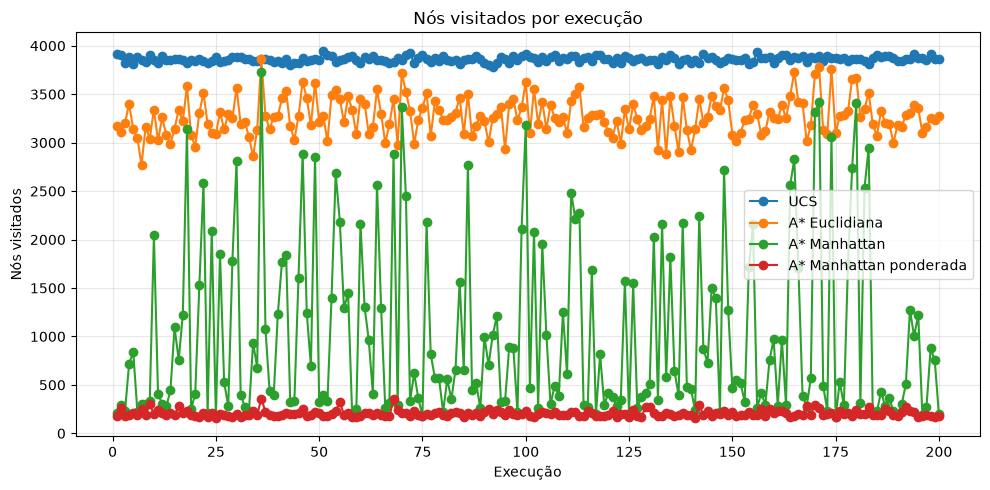

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for algorithm_name, results in comparison_history.items():
    runs = [item["run"] for item in results]
    values = [item["nodes_visited"] for item in results]
    plt.plot(runs, values, marker="o", label=algorithm_name)

plt.title("Nós visitados por execução")
plt.xlabel("Execução")
plt.ylabel("Nós visitados")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


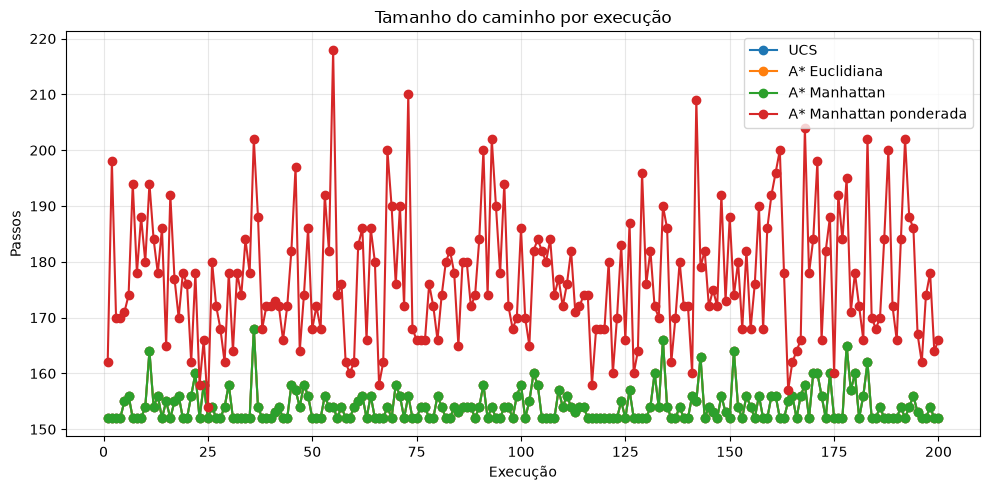

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for algorithm_name, results in comparison_history.items():
    runs = [item["run"] for item in results]
    values = [item["path_length"] for item in results]
    plt.plot(runs, values, marker="o", label=algorithm_name)

plt.title("Tamanho do caminho por execução")
plt.xlabel("Execução")
plt.ylabel("Passos")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


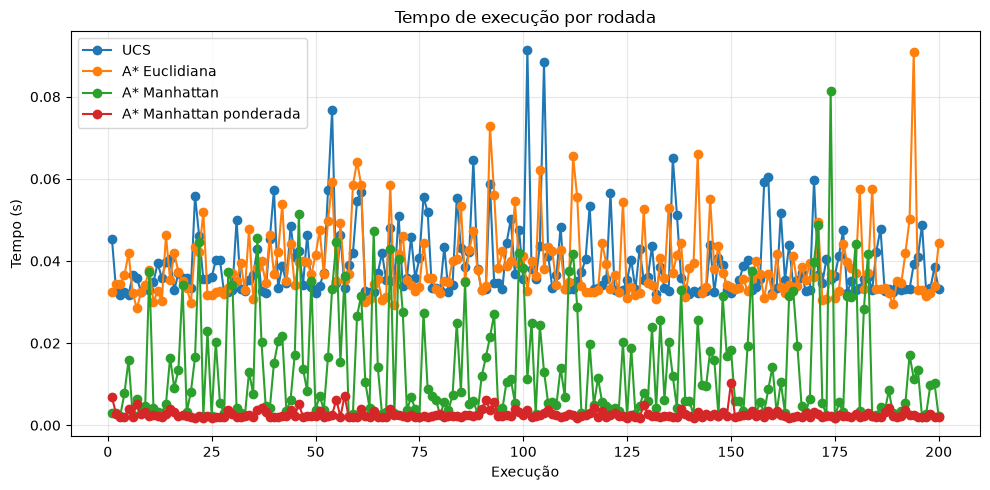

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for algorithm_name, results in comparison_history.items():
    runs = [item["run"] for item in results]
    values = [item["execution_time_sec"] for item in results]
    plt.plot(runs, values, marker="o", label=algorithm_name)

plt.title("Tempo de execução por rodada")
plt.xlabel("Execução")
plt.ylabel("Tempo (s)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


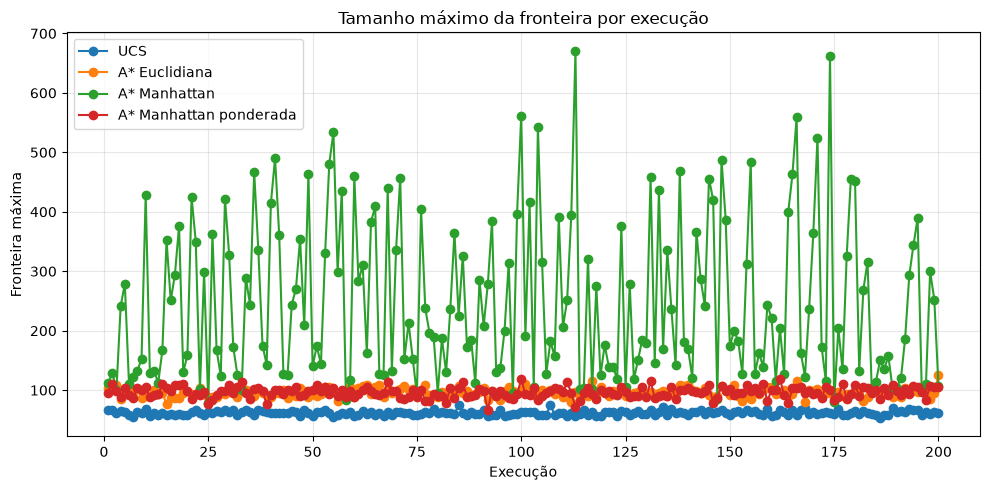

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for algorithm_name, results in comparison_history.items():
    runs = [item["run"] for item in results]
    values = [item["max_frontier_size"] for item in results]
    plt.plot(runs, values, marker="o", label=algorithm_name)

plt.title("Tamanho máximo da fronteira por execução")
plt.xlabel("Execução")
plt.ylabel("Fronteira máxima")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
from statistics import mean, median

# Experimentos para observar escala da arena e quantidade de loops.
scaling_sizes = [7, 11, 15, 19]
scaling_loop_probabilities = [0.0, 0.1, 0.3]
scaling_samples = 5


def count_maze_loops(maze: Maze) -> int:
    """Calcula o número de ciclos independentes no grafo de passagens."""
    open_cells = [
        (row, column)
        for row in range(maze.height)
        for column in range(maze.width)
        if (row, column) not in maze.walls
    ]
    edge_count = sum(
        len(list(maze.neighbors(position)))
        for position in open_cells
    ) // 2

    # Para um grafo conectado, ciclos = arestas - vértices + 1.
    return edge_count - len(open_cells) + 1


scaling_results = []
for size in scaling_sizes:
    for loop_index, loop_probability in enumerate(scaling_loop_probabilities):
        for sample in range(scaling_samples):
            seed = 10000 + size * 100 + loop_index * 10 + sample
            maze = MazeGenerator(
                size,
                size,
                seed=seed,
                loop_probability=loop_probability,
            ).generate()
            loop_count = count_maze_loops(maze)

            # Todos os algoritmos recebem exatamente este mesmo labirinto.
            for algorithm_name, heuristic in algorithms_to_compare:
                result = search_maze(maze, heuristic, algorithm_name)
                scaling_results.append({
                    "size": size,
                    "loop_probability": loop_probability,
                    "loop_count": loop_count,
                    "sample": sample + 1,
                    "algorithm": algorithm_name,
                    "nodes_visited": result["nodes_visited"],
                    "path_length": result["path_length"],
                    "execution_time_sec": result["execution_time_sec"],
                    "max_frontier_size": result["max_frontier_size"],
                    "status": result["status"],
                })


# Agrupa as amostras por tamanho, loops e algoritmo.
groups = {}
for result in scaling_results:
    key = (
        result["size"],
        result["loop_probability"],
        result["algorithm"],
    )
    groups.setdefault(key, []).append(result)

scaling_summary = []
for (size, loop_probability, algorithm_name), results in groups.items():
    summary = {
        "size": size,
        "loop_probability": loop_probability,
        "algorithm": algorithm_name,
        "mean_loop_count": mean(item["loop_count"] for item in results),
        "median_loop_count": median(item["loop_count"] for item in results),
    }
    for metric in (
        "nodes_visited",
        "path_length",
        "execution_time_sec",
        "max_frontier_size",
    ):
        values = [item[metric] for item in results]
        summary[f"mean_{metric}"] = mean(values)
        summary[f"median_{metric}"] = median(values)
    scaling_summary.append(summary)

print(
    f"{len(scaling_results)} resultados coletados "
    f"({len(scaling_sizes)} tamanhos x "
    f"{len(scaling_loop_probabilities)} níveis de loops x "
    f"{scaling_samples} amostras x "
    f"{len(algorithms_to_compare)} algoritmos)."
)
print()
print(
    f"{'Arena':>5} {'Loops p':>8} {'Algoritmo':<26} "
    f"{'Loops méd.':>11} {'Tempo médio':>14} {'Tempo mediano':>16} "
    f"{'Nós médios':>12} {'Nós medianos':>14}"
)
print("-" * 122)
for summary in scaling_summary:
    print(
        f"{summary['size']:>5} "
        f"{summary['loop_probability']:>8.1f} "
        f"{summary['algorithm']:<26} "
        f"{summary['mean_loop_count']:>11.2f} "
        f"{summary['mean_execution_time_sec']:>14.6f} "
        f"{summary['median_execution_time_sec']:>16.6f} "
        f"{summary['mean_nodes_visited']:>12.2f} "
        f"{summary['median_nodes_visited']:>14.2f}"
    )


240 resultados coletados (4 tamanhos x 3 níveis de loops x 5 amostras x 4 algoritmos).

Arena  Loops p Algoritmo                   Loops méd.    Tempo médio    Tempo mediano   Nós médios   Nós medianos
--------------------------------------------------------------------------------------------------------------------------
    7      0.0 UCS                               0.00       0.000158         0.000150        17.00          17.00
    7      0.0 A* Euclidiana                     0.00       0.000171         0.000178        15.40          17.00
    7      0.0 A* Manhattan                      0.00       0.000171         0.000172        15.40          17.00
    7      0.0 A* Manhattan ponderada            0.00       0.000161         0.000164        15.40          17.00
    7      0.1 UCS                               1.60       0.000235         0.000206        18.20          17.00
    7      0.1 A* Euclidiana                     1.60       0.001489         0.000336        14.80       

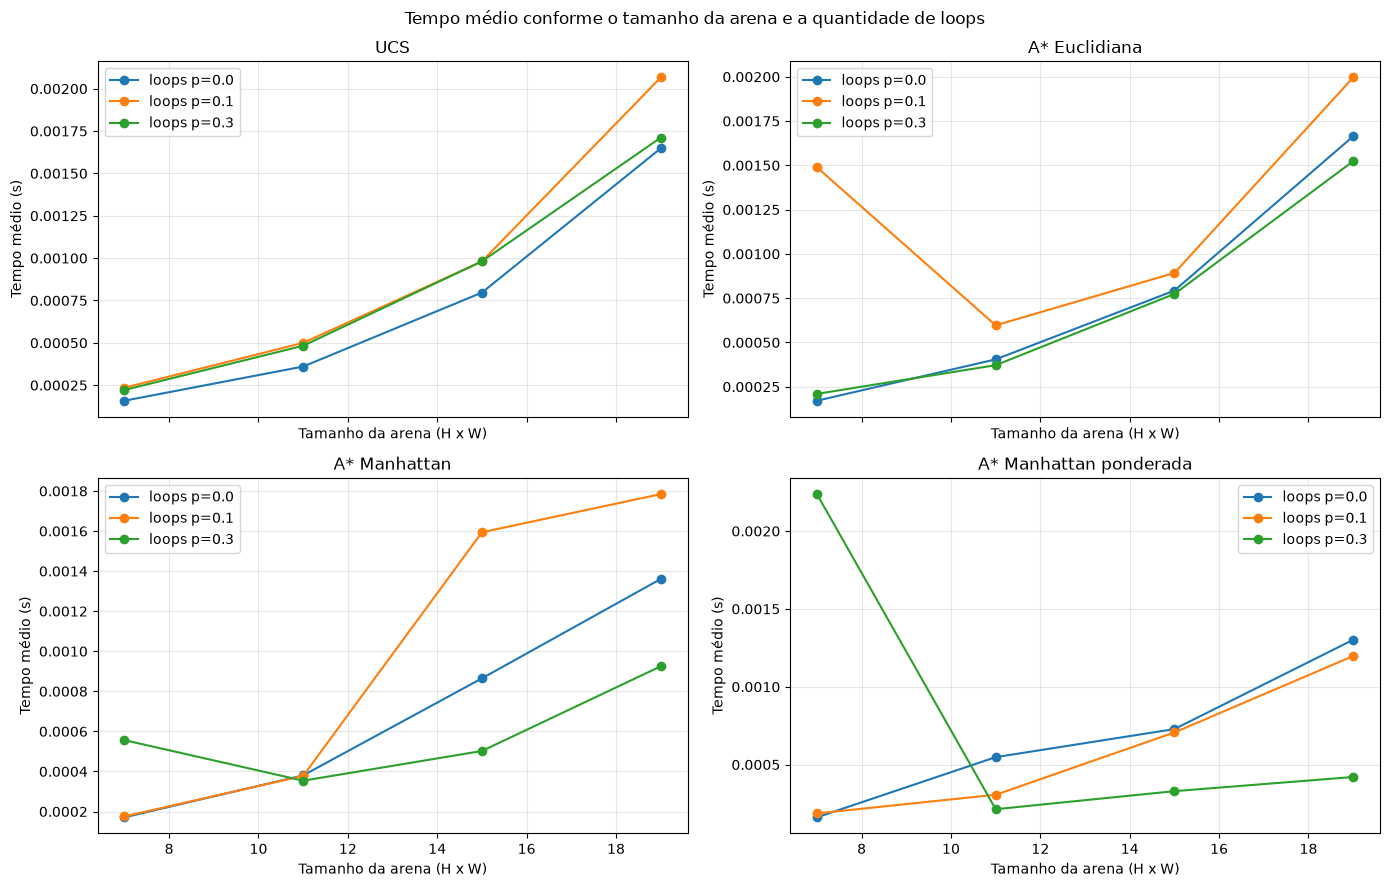

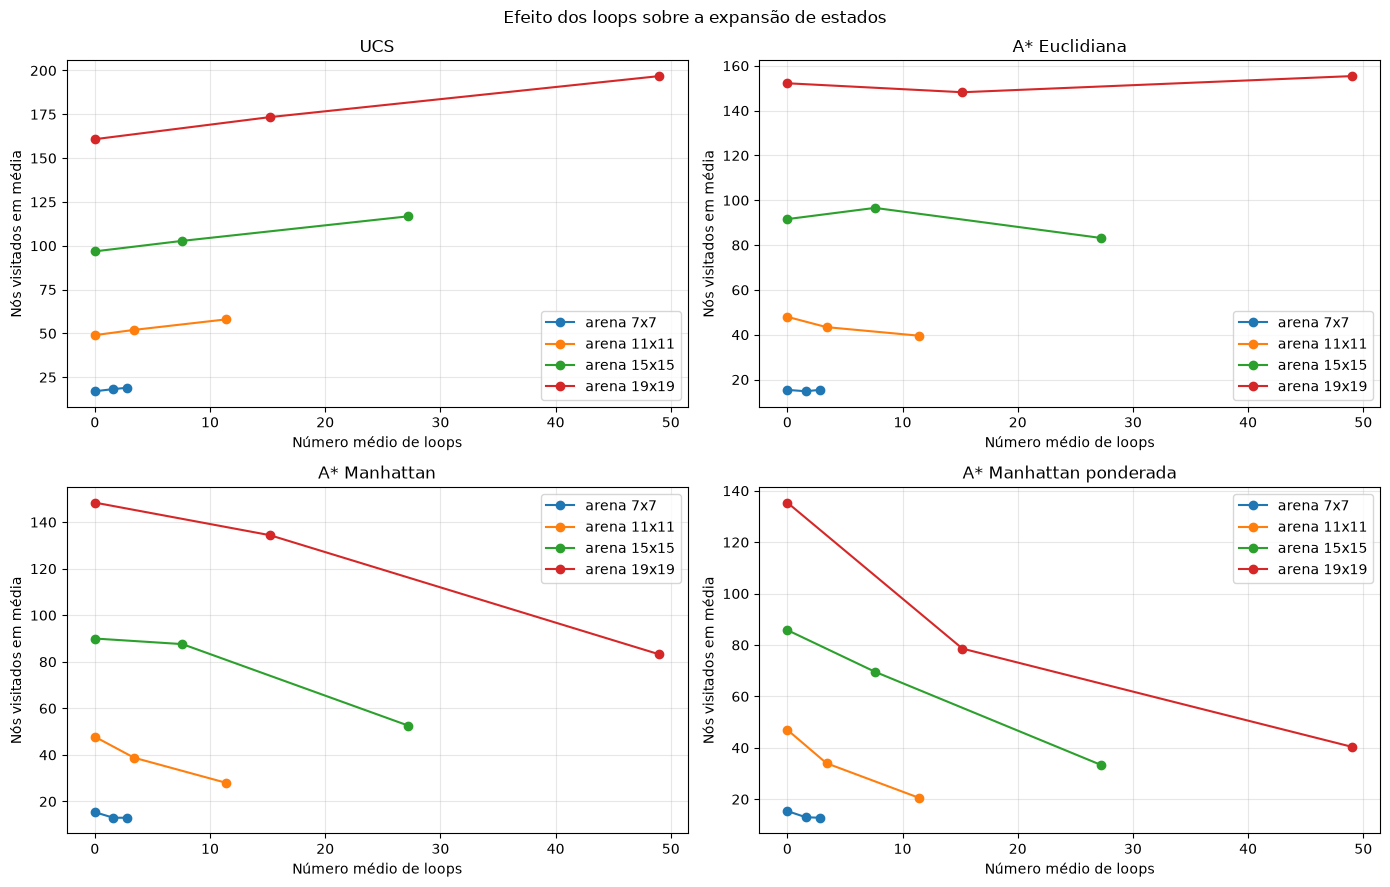

In [18]:
import matplotlib.pyplot as plt

# Tempo médio conforme o tamanho da arena, separado por algoritmo.
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.ravel()

for axis, (algorithm_name, _) in zip(axes, algorithms_to_compare):
    for loop_probability in scaling_loop_probabilities:
        rows = [
            row
            for row in scaling_summary
            if row["algorithm"] == algorithm_name
            and row["loop_probability"] == loop_probability
        ]
        rows.sort(key=lambda row: row["size"])
        axis.plot(
            [row["size"] for row in rows],
            [row["mean_execution_time_sec"] for row in rows],
            marker="o",
            label=f"loops p={loop_probability}",
        )

    axis.set_title(algorithm_name)
    axis.set_xlabel("Tamanho da arena (H x W)")
    axis.set_ylabel("Tempo médio (s)")
    axis.grid(True, alpha=0.3)
    axis.legend()

fig.suptitle("Tempo médio conforme o tamanho da arena e a quantidade de loops")
fig.tight_layout()
plt.show()

# Nós visitados conforme a quantidade de loops real do labirinto.
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
axes = axes.ravel()

for axis, (algorithm_name, _) in zip(axes, algorithms_to_compare):
    for size in scaling_sizes:
        rows = [
            row
            for row in scaling_summary
            if row["algorithm"] == algorithm_name
            and row["size"] == size
        ]
        rows.sort(key=lambda row: row["mean_loop_count"])
        axis.plot(
            [row["mean_loop_count"] for row in rows],
            [row["mean_nodes_visited"] for row in rows],
            marker="o",
            label=f"arena {size}x{size}",
        )

    axis.set_title(algorithm_name)
    axis.set_xlabel("Número médio de loops")
    axis.set_ylabel("Nós visitados em média")
    axis.grid(True, alpha=0.3)
    axis.legend()

fig.suptitle("Efeito dos loops sobre a expansão de estados")
fig.tight_layout()
plt.show()
